In [ ]:
#Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Load iris Dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


In [ ]:
#Normalize the data
scaler = StandardScaler()

X = scaler.fit_transform(X)

print(X[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [ ]:
#Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [ ]:
#Create the MLP Model
def create_model(lr):

    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
#Analyze learning rates
learning_rates = [0.1, 0.01, 0.001]

results = []

for lr in learning_rates:

    model = create_model(lr)

    model.fit(
        X_train,
        y_train,
        epochs=50,
        verbose=0
    )

    loss, acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append([lr, acc])

df = pd.DataFrame(
    results,
    columns=["Learning Rate", "Accuracy"]
)

print(df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Accuracy
0          0.100       1.0
1          0.010       1.0
2          0.001       0.9


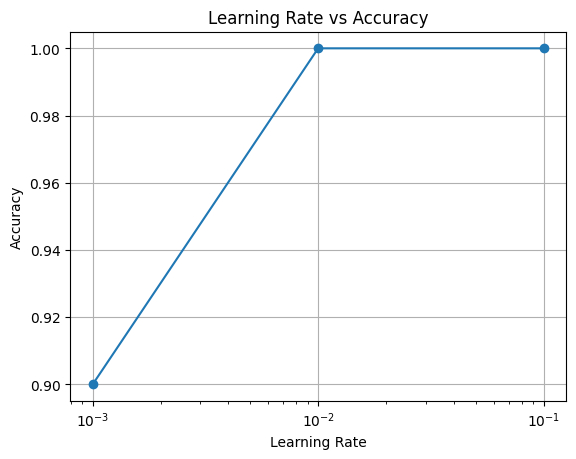

In [ ]:
#Plot learning rate vs accuracy
plt.plot(
    df["Learning Rate"],
    df["Accuracy"],
    marker="o"
)

plt.xscale("log")
plt.title("Learning Rate vs Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.grid()

plt.show()

In [ ]:
#Analyze epochs
epochs_list = [10, 50, 100]

results = []

for ep in epochs_list:

    model = create_model(0.001)

    model.fit(
        X_train,
        y_train,
        epochs=ep,
        validation_split=0.2,
        verbose=0
    )

    loss, acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append([ep, acc])

edf = pd.DataFrame(
    results,
    columns=["Epochs", "Accuracy"]
)

print(edf)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0      10  0.533333
1      50  0.733333
2     100  0.900000


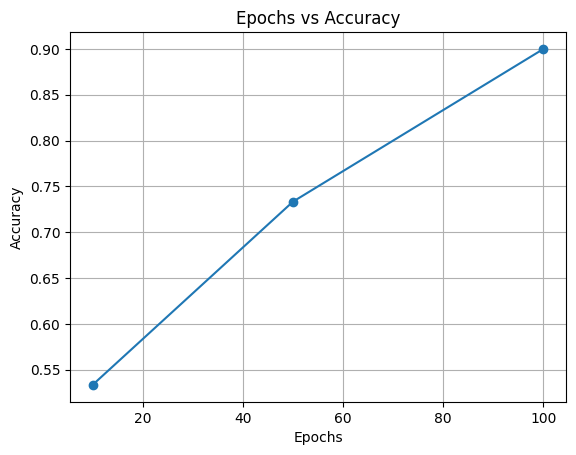

In [ ]:
#Plot epoch vs accuracy
plt.plot(
    edf["Epochs"],
    edf["Accuracy"],
    marker="o"
)

plt.title("Epochs vs Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid()

plt.show()

In [ ]:
#Train the final model
model = create_model(0.001)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.3542 - loss: 1.1546 - val_accuracy: 0.1667 - val_loss: 1.1527
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4062 - loss: 1.1388 - val_accuracy: 0.2083 - val_loss: 1.1331
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4479 - loss: 1.1238 - val_accuracy: 0.2500 - val_loss: 1.1150
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4688 - loss: 1.1100 - val_accuracy: 0.2917 - val_loss: 1.0978
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5104 - loss: 1.0968 - val_accuracy: 0.3750 - val_loss: 1.0813
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5417 - loss: 1.0840 - val_accuracy: 0.4167 - val_loss: 1.0656
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5729 - loss: 1.0718 - val_accuracy: 0.5000 - val_loss: 1.0498
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6354 - loss: 1.0583 - val_accuracy: 0.5000 - val_loss: 1.0354
Epoch 9/50

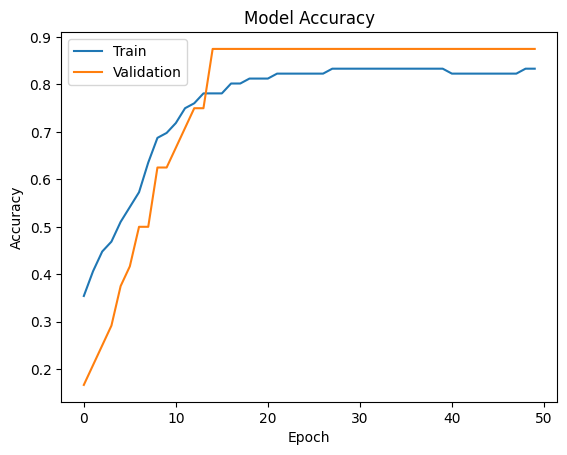

In [ ]:
#Accuracy graph
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

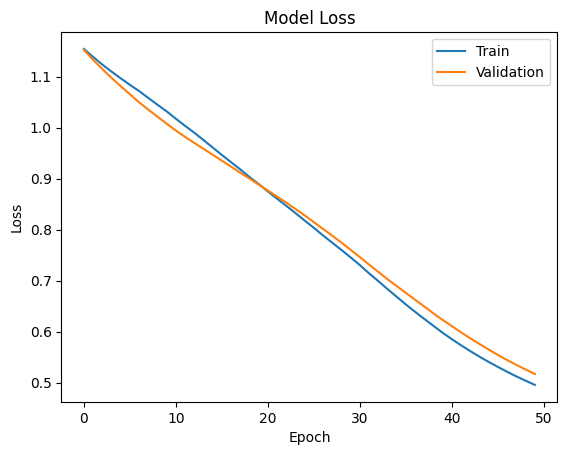

In [ ]:
#Loss graph
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
#Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9000 - loss: 0.4567
Test Accuracy: 0.8999999761581421
Test Loss: 0.4567069113254547
